In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, recall_score
from sklearn.ensemble import AdaBoostClassifier

## Loading the data

In [2]:
data = pd.read_csv('P53_Etoposide.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7467 entries, 0 to 7466
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mutant            7467 non-null   object 
 1   mutated_sequence  7467 non-null   object 
 2   DMS_score         7467 non-null   float64
 3   DMS_score_bin     7467 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 233.5+ KB


In [ ]:
# Display the first few rows of the dataset
data.head()

,mutant,mutated_sequence,DMS_score,DMS_score_bin
0,M1A,AEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.788753,0
1,M1C,CEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.969077,0
2,M1Y,YEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.333315,0
3,M1W,WEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-2.219256,0
4,M1V,VEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.669727,0


### Data Structure

The column "mutant" provides a summary of each variant in three components: the first letter reflects the wild-type state at the mutated position, the number reflects the position at which the variant was mutated, and the third letter reflects the mutant state at that position. 

"mutated_sequence" is full the amino acid sequence of the variant (wild-type, save the mutant position). 

DMS_score is the log-normalized functional score of the mutant.

"DMS_score_bin" is the binarized version of DMS_score, where 1 indicates a functional mutant and 0 indicates a non-functional mutant.

In [ ]:
# Display summary statistics for the DMS_score column
data["DMS_score"].describe()

count    7467.000000
mean        0.046731
std         0.978440
min        -3.943922
25%        -0.499698
50%         0.350252
75%         0.738673
max         2.533067
Name: DMS_score, dtype: float64

This single DMS dataset is complete. We have 7467 variants to work with, reflecting the 19 alternative amino acid states at all 393 positions in the sequence.

## Data Exploration

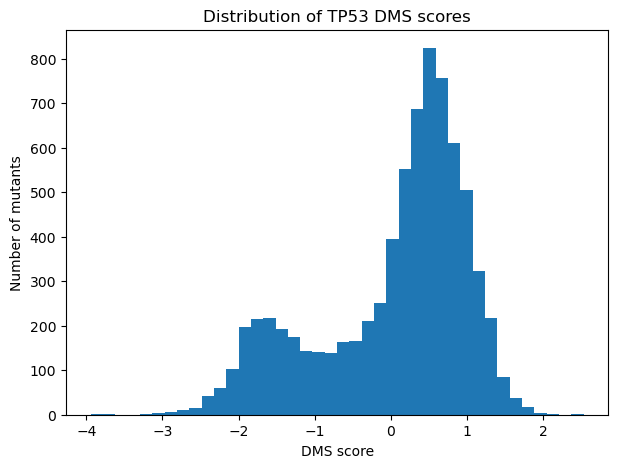

In [ ]:
# Plot the distribution of DMS scores
plt.figure(figsize=(7, 5))
plt.hist(data["DMS_score"], bins=40)
plt.xlabel("DMS score")
plt.ylabel("Number of mutants")
plt.title("Distribution of TP53 DMS scores")
plt.show()

The above plot shows us the distribution of DMS scores of the mutants in our data. They are not evenly distributed and instead occupy a bimodal distribution. The bulk of the mutants have scores between 0 and 1, which suggests that many of the mutations have mild or neutral effects. There is a second significant group centered between -1 and -2, which tells us that a subset of the mutations are deleterious. 

This spread supports predicting on the binary DMS_score_bin. While scores are continuous, there are two clear modes and a meaningful boundary between the categories. Further, the medically-relevant phenotypic value here is Loss-of-Function, where the protein is no longer able to suppress tumor growth. As such, predicting binary function is more clinically relevant.

Now let's check how balanced the data is.

In [ ]:
# viewing class imbalance in the dataset
n_functional  = data.DMS_score_bin.sum()
n_nonfunctional = len(data) - n_functional
print(f'Functional  : {n_functional}  ({n_functional/len(data)*100:.1f}%)')
print(f'Nonfunctional : {n_nonfunctional} ({n_nonfunctional/len(data)*100:.1f}%)')

Functional  : 5601  (75.0%)
Nonfunctional : 1866 (25.0%)


Not the most balanced dataset, but this reflects the biological reality. Could be worse. We will see how this affects each model.

In [7]:
# We can extract information about the position of the mutation. 
# The "mutant" column has format X123Y, where X is the wild-type amino acid, 
# 123 is the position of the mutation, and Y is the mutant amino acid.

data["position"] = data["mutant"].str.extract(r"(\d+)").astype(int)
data["wt_aa"] = data["mutant"].str[0]
data["mut_aa"] = data["mutant"].str[-1]

data.head()

,mutant,mutated_sequence,DMS_score,DMS_score_bin,position,wt_aa,mut_aa
0,M1A,AEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.788753,0,1,M,A
1,M1C,CEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.969077,0,1,M,C
2,M1Y,YEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.333315,0,1,M,Y
3,M1W,WEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-2.219256,0,1,M,W
4,M1V,VEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.669727,0,1,M,V


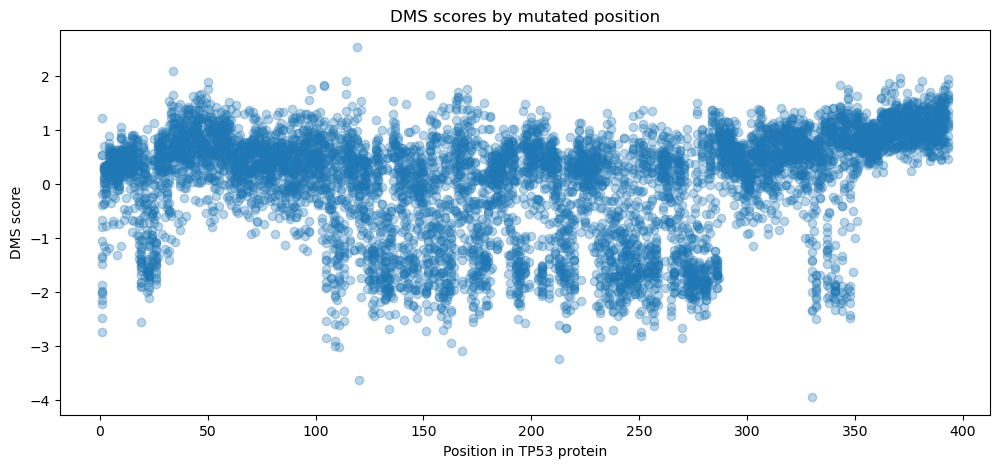

In [ ]:
# Plot DMS scores by mutated position
plt.figure(figsize=(12, 5))
plt.scatter(data["position"], data["DMS_score"], alpha=0.3)

plt.xlabel("Position in TP53 protein")
plt.ylabel("DMS score")
plt.title("DMS scores by mutated position")
plt.show()

This scatterplot shows the DMS score for each mutation across positions in the TP53 protein. Each point represents one variant, wherein a single position along the protein has been mutated to a single alternative amino acid. As such, there are 19 variants per position. 

This plot tells us that the mutational effects are not evenly distributed across TP53's amino acid sequence. Some regions, such as the C terminus (near the end of the protein's sequence), are more tolerant of mutations and show a high concentration of neutral to beneficial mutations, and few if any negative scores. Positions 100-300 show many low DMS scores, which indicates that mutation in these regions is very detrimental to the function of the protein.

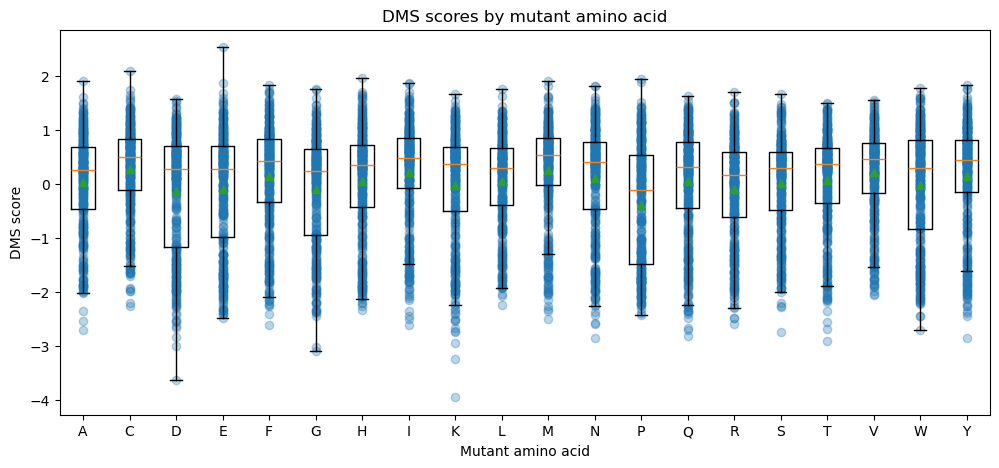

In [ ]:
# Plot DMS scores by mutant amino acid
aa_order = sorted(data['mutant'].str[-1].unique())
x_map = {aa: i for i, aa in enumerate(aa_order, 1)}  # start at 1 to match boxplot - otherwise misaligned :/

plt.figure(figsize=(12, 5))
plt.scatter(data['mutant'].str[-1].map(x_map), data["DMS_score"], alpha=0.3)

grouped = [data[data['mutant'].str[-1] == aa]["DMS_score"].values for aa in aa_order]
plt.boxplot(grouped, showmeans=True, sym='')

plt.xticks(ticks=list(range(1, 21)), labels=aa_order)
plt.xlabel("Mutant amino acid")
plt.ylabel("DMS score")
plt.title("DMS scores by mutant amino acid")
plt.show()

Above, the orange line reflects the median DMS score while the green triangle reflects the mean. We can see that there are overall trends in mutational effect by amino acid, but that there is a lot of variance. None are consistently positive or negative, though some seem to have much tighter spreads than others (compare the inner two quartiles for M, methionine, versus P, proline).

## Data Processing

In [10]:
# define the Atchley factor dictionary, with a value for each AA corresponding to a vector of the 5 factors
atchley = {
    'A': [-0.591, -1.302, -0.733,  1.570, -0.146],
    'C': [-1.343,  0.465, -0.862, -1.020, -0.255],
    'D': [ 1.050,  0.302, -3.656, -0.259, -3.242],
    'E': [ 1.357, -1.453,  1.477,  0.113, -0.837],
    'F': [-1.006, -0.590,  1.891, -0.397,  0.412],
    'G': [-0.384,  1.652,  1.330,  1.045,  2.064],
    'H': [ 0.336, -0.417, -1.673, -1.474, -0.078],
    'I': [-1.239, -0.547,  2.131,  0.393,  0.816],
    'K': [ 1.831, -0.561,  0.533, -0.277,  1.648],
    'L': [-1.019, -0.987, -1.505,  1.266, -0.912],
    'M': [-0.663, -1.524,  2.219, -1.005,  1.212],
    'N': [ 0.945,  0.828,  1.299, -0.169,  0.933],
    'P': [ 0.189,  2.081, -1.628,  0.421, -1.392],
    'Q': [ 0.931, -0.179, -3.005, -0.503, -1.853],
    'R': [ 1.538, -0.055,  1.502,  0.440,  2.897],
    'S': [-0.228,  1.399, -4.760,  0.670, -2.647],
    'T': [-0.032,  0.326,  2.213,  0.908,  1.313],
    'V': [-1.337, -0.279, -0.544,  1.242, -1.262],
    'W': [-0.595,  0.009,  0.672, -2.128, -0.184],
    'Y': [ 0.260,  0.830,  3.097, -0.838,  1.512]
}

In [11]:
# data extraction from column 'mutant'
## atchley factor conversion for mutant and wildtype followed by subtraction
## position encoded as a sixth feature to avoid having extremely sparse samples
#### ex. M1A -> wt atchley for M, mut atchley for A, position = 1

def encode_mutant(mutant_str):
    wt_aa = mutant_str[0]
    mut_aa = mutant_str[-1]
    position = int(mutant_str[1:-1])
    delta = np.array(atchley[mut_aa]) - np.array(atchley[wt_aa])
    return np.append(delta, position)


# convert data and collate rows (1 row = 1 mutant)
X = np.vstack([encode_mutant(m) for m in data['mutant']])


We now have a vertical stack, where each row corresponds to an entry in our original DMS csv. These rows comprise the five $\Delta$ Atchley factors, found by subtracting the wild type amino acid's Atchley vector from the mutant amino acid's Atchley vector, plus a sixth feature reflecting the position along the protein's sequence. We can use this stack to train our models.

# Training the Models

## Model 1: Gaussian Naive Bayes

We selected Gaussian Naive Bayes as our first model since our features, Atchley Factors, are roughly normally distributed in five continuous dimensions.

In [12]:
# this is the target variable, the DMS score bin 
y = data["DMS_score_bin"]

In [13]:
# Feature matrix: Atchley factor difference + position
feature_names = [
    "atchley_1_change",
    "atchley_2_change",
    "atchley_3_change",
    "atchley_4_change",
    "atchley_5_change",
    "position"
]

X_df = pd.DataFrame(X, columns=feature_names)

X_df.head()

,atchley_1_change,atchley_2_change,atchley_3_change,atchley_4_change,atchley_5_change,position
0,0.072,0.222,-2.952,2.575,-1.358,1.0
1,-0.680,1.989,-3.081,-0.015,-1.467,1.0
2,0.923,2.354,0.878,0.167,0.300,1.0
3,0.068,1.533,-1.547,-1.123,-1.396,1.0
4,-0.674,1.245,-2.763,2.247,-2.474,1.0


In [14]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_df,
    y,
    test_size=0.2,
    random_state=42,

    #stratify y in order to maintain the same proportion of classes in train and test sets
    stratify=y
)

In [15]:
# train the model
gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)
y_prob = gnb.predict_proba(X_test)[:, 1]

In [16]:
# evaluation

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC AUC:", roc_auc)
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.7570281124497992
ROC AUC: 0.7308942370011455

              precision    recall  f1-score   support

           0       0.55      0.14      0.22       373
           1       0.77      0.96      0.86      1121

    accuracy                           0.76      1494
   macro avg       0.66      0.55      0.54      1494
weighted avg       0.72      0.76      0.70      1494



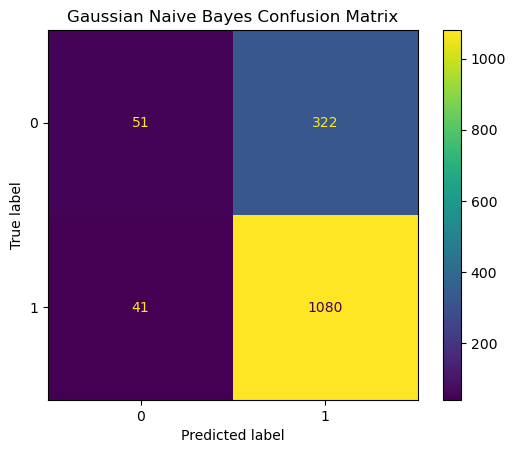

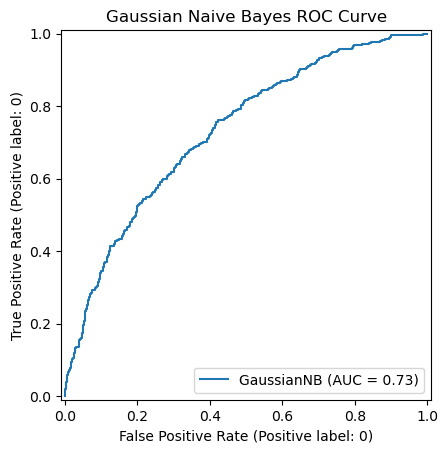

In [17]:
# confusion matrix and roc curve
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gnb.classes_)
disp.plot()
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(gnb, X_test, y_test, pos_label=0)
plt.title("Gaussian Naive Bayes ROC Curve")
plt.show()

The model achieved an accuracy of about 0.78 and an ROC AUC of about 0.73. However, the confusion matrix shows that the model strongly favored predicting the functional class, correctly identifying most class 1 variants but missing many class 0 variants. This means that the model does learn some useful signal from the Atchley encoding, but it performs poorly at detecting loss-of-function mutations. Because most of the sample is a positive mutation class 1, the model could still perform at this accuracy if it predicts class 1 at every sample. 

To check class-specific performance, let's check Macro F1 score. Macro F1 score may be more informative here due to our class imbalance. It averages performance by class equally, rather than by true count. Poor performance on the minority class (here, the clinically relevant nonfunctional variants) is not diluted by performance on the majority class. We'll also assess the recall on the clinically relevant class: Class 0. 

In [18]:
print(f1_score(y_test, y_pred, average='macro'))

0.5377392505082275


In [19]:
recall_0 = recall_score(y_test, y_pred, pos_label=0)
print(f"Recall on LOF class: {recall_0:.3f}")

Recall on LOF class: 0.137


Our Macro F1 score is slightly higher than by random chance, reflecting that we are capturing some true underlying structure to the data. Unfortunately, our recall on the clinically relevant class is quite low. This model only correctly flags 13.7% of LOF cases.

## Ensemble Decision Tree - AdaBoost

We selected an ensemble decision tree as our second model as it is biologically plausible that there may be linear thresholds along each Atchley factor dimension that cause loss of function. We specifically selected AdaBoost as our ensemble so that it can reweight incorrect predictions. 

Let's establish a baseline with 100 stumps.

In [ ]:
# We can see that the model is performing decently, but there is room for improvement.
# Let's try a different model, AdaBoost, which is an ensemble method that can often improve
# performance by combining multiple weak learners (like decision trees) into a stronger model.
model_ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42,
    algorithm='SAMME'
)
model_ada.fit(X_train, y_train)

y_train_hat = model_ada.predict(X_train)
y_hat       = model_ada.predict(X_test)
y_prob      = model_ada.predict_proba(X_test)[:, 1]

print(f"AdaBoost  —  Train F1: {f1_score(y_train, y_train_hat):.3f}")
print(f"AdaBoost  —  Test F1:  {f1_score(y_test, y_hat):.3f}")

/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost  —  Train F1: 0.867
AdaBoost  —  Test F1:  0.870


As before, let's check Macro F1 score.

In [21]:
print(f1_score(y_test, y_hat, average='macro'))

0.6908154404265622


Now let's check how many stumps we need. We want to improve Test F1 without dramatically increasing compute usage, so we should assess the point of diminishing returns. Let's stick with Macro F1 to assess.

n=10     train=0.429  test=0.429
n=50     train=0.618  test=0.608


/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


n=100    train=0.684  test=0.691


/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


n=250    train=0.705  test=0.705


...

n=3000   train=0.782  test=0.764


/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


n=4000   train=0.798  test=0.780


/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


n=5000   train=0.803  test=0.780


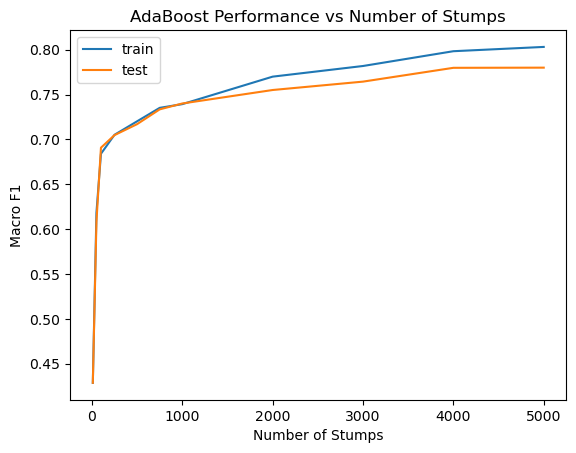

In [ ]:
# Let's see how the number of stumps (weak learners) in the AdaBoost model affects performance.
stump_counts = [10, 50, 100, 250, 500, 750, 1000, 2000, 3000, 4000, 5000]
results = []

for n in stump_counts:
    model = AdaBoostClassifier(n_estimators=n, random_state=42, algorithm='SAMME')
    model.fit(X_train, y_train)
    train_f1 = f1_score(y_train, model.predict(X_train), average='macro')
    test_f1  = f1_score(y_test,  model.predict(X_test),  average='macro')
    results.append((n, train_f1, test_f1))
    print(f"n={n:<6} train={train_f1:.3f}  test={test_f1:.3f}")

# plot it
ns, train_f1s, test_f1s = zip(*results)
plt.plot(ns, train_f1s, label='train')
plt.plot(ns, test_f1s,  label='test')
plt.xlabel('Number of Stumps')
plt.ylabel('Macro F1')
plt.title('AdaBoost Performance vs Number of Stumps')
plt.legend()
plt.show()

We can see the test line plateaus around 4000. I'll use that many stumps.

In [ ]:
# We can see that performance improves as we increase the number of stumps, but it starts to plateau around 4000 stumps. 
# Let's use that as our final model.
model_ada = AdaBoostClassifier(
    n_estimators=4000,
    random_state=42,
    algorithm='SAMME'
)
model_ada.fit(X_train, y_train)

y_train_hat = model_ada.predict(X_train)
y_hat       = model_ada.predict(X_test)
y_prob      = model_ada.predict_proba(X_test)[:, 1]

print(f"AdaBoost  —  Train F1: {f1_score(y_train, y_train_hat):.3f}")
print(f"AdaBoost  —  Test F1:  {f1_score(y_test, y_hat):.3f}")

/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost  —  Train F1: 0.908
AdaBoost  —  Test F1:  0.900


Nice! Looks like only marginal overfitting to the training data.

In [ ]:
# evaluation metrics for final model

accuracy = accuracy_score(y_test, y_hat)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC AUC:", roc_auc)
print()
print(classification_report(y_test, y_hat))

Accuracy: 0.8453815261044176
ROC AUC: 0.8851752911155064

              precision    recall  f1-score   support

           0       0.73      0.60      0.66       373
           1       0.87      0.93      0.90      1121

    accuracy                           0.85      1494
   macro avg       0.80      0.76      0.78      1494
weighted avg       0.84      0.85      0.84      1494



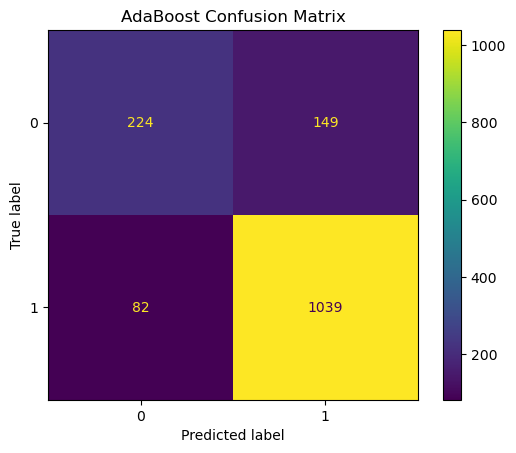

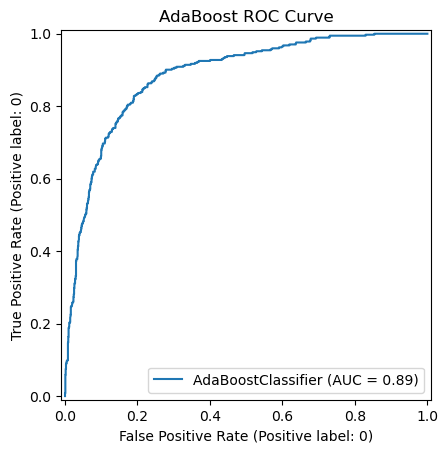

In [ ]:
# confusion matrix and roc curve for final model
cm = confusion_matrix(y_test, y_hat)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_ada.classes_)
disp.plot()
plt.title("AdaBoost Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(model_ada, X_test, y_test, pos_label=0)
plt.title("AdaBoost ROC Curve")
plt.show()

The model achieved a Macro F1 score of 0.9 on the training set and an AUC of 0.89. The confusion matrix shows that AdaBoost predicts Nonfunctional (DMS_score_bin = 0) more often than our Naive Bayes classifier did. It does predict false positives more often than false negatives, as was true in Naive Bayes. Since this is the minority class, it's definitely not a simple consequence of count. Our model is preferentially predicting Functional for Nonfunctional variants more often than the reverse case.

In [39]:
recall_0 = recall_score(y_test, y_hat, pos_label=0)
print(f"Recall on LOF class: {recall_0:.3f}")

Recall on LOF class: 0.601


Our recall of the clinically relevant class is much higher than with naive Bayes! We are now capturing 60% of true LOF variants.

# Assessing Generalizability

Giacomelli et al., the authors of the original paper containing this data, also provided an additonal dataset of this same library under an alternative drug treatments. For further detail, see full Report. We are going to assess here whether our better performing model, AdaBoost, is able to correctly classify variants under Nutlin treatment. Since our model will be trained on TP53 function under Etoposide conditions, it has no information about Nutlin-specific activation pathways and we expect performance to drop.

We can now use the full Etoposide dataset to train.

In [40]:
# loading the additional drugged dataset
nutlin = pd.read_csv('P53_Nutlin.csv')
data.info()
nutlin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7467 entries, 0 to 7466
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mutant            7467 non-null   object 
 1   mutated_sequence  7467 non-null   object 
 2   DMS_score         7467 non-null   float64
 3   DMS_score_bin     7467 non-null   int64  
 4   position          7467 non-null   int64  
 5   wt_aa             7467 non-null   object 
 6   mut_aa            7467 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 408.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7467 entries, 0 to 7466
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mutant            7467 non-null   object 
 1   mutated_sequence  7467 non-null   object 
 2   DMS_score         7467 non-null   float64
 3   DMS_score_bin     7467 non-null   int64  
dtypes: float64(1),

In [41]:
# class imbalances
n_functional  = data.DMS_score_bin.sum()
n_nonfunctional = len(data) - n_functional
print(f'Etoposide Functional  : {n_functional}  ({n_functional/len(data)*100:.1f}%)')
print(f'Etoposide Nonfunctional : {n_nonfunctional} ({n_nonfunctional/len(data)*100:.1f}%)')

n_functional  = nutlin.DMS_score_bin.sum()
n_nonfunctional = len(nutlin) - n_functional
print(f'Nutlin Functional  : {n_functional}  ({n_functional/len(nutlin)*100:.1f}%)')
print(f'Nutlin Nonfunctional : {n_nonfunctional} ({n_nonfunctional/len(nutlin)*100:.1f}%)')

Etoposide Functional  : 5601  (75.0%)
Etoposide Nonfunctional : 1866 (25.0%)
Nutlin Functional  : 3734  (50.0%)
Nutlin Nonfunctional : 3733 (50.0%)


Looks like under Etoposide treatment we see a 75:25 ratio of functional to nonfunctional, but under Nutlin treatment we see far fewer functional variants (50:50).

Let's check how often the labels match between the Etoposide case and the Nutlin case. If they match, we expect higher prediction accuracy, although this is really cheating our way there. It's not generalizing so much as memorizing relationships between Atchley features and labels.

In [ ]:
# comparing the two datasets
merged = data[['mutant', 'DMS_score_bin']].merge(
    nutlin[['mutant', 'DMS_score_bin']], 
    on='mutant', 
    suffixes=('_etopo', '_nutlin')
)

agreement = (merged['DMS_score_bin_etopo'] == merged['DMS_score_bin_nutlin']).sum()
print(f"Agreeing labels: {agreement} / {len(merged)} ({agreement/len(merged):.1%})")

Agreeing labels: 5440 / 7467 (72.9%)


A fairly good match. This should perform pretty well, but we do have about 27% of our data that the model has never seen before.

Moving on. We'll stick with 4000 stumps here but train on the full dataset.

In [ ]:
# featurizing the  dataset
X_nutlin = np.vstack([encode_mutant(m) for m in nutlin['mutant']])

y_nutlin = nutlin["DMS_score_bin"]

In [ ]:
# evaluating the final model on the nutlin dataset
full_model_ada = AdaBoostClassifier(
    n_estimators=4000,
    random_state=42,
    algorithm='SAMME'
)
full_model_ada.fit(X_df, y)

y_hat_nutlin = full_model_ada.predict(X_nutlin)

print(f"Nutlin F1:     {f1_score(y_nutlin, y_hat_nutlin, average='macro'):.3f}")

/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


Etoposide F1:  0.789
Nutlin F1:     0.609


These F1 scores are greater than random chance but lower than our value for the model trained on wild-type, tested on wild-type (0.9).

In [ ]:
recall_nutlin = recall_score(y_nutlin, y_hat_nutlin, pos_label=0)

print(f"Recall on LOF class (Nutlin):    {recall_nutlin:.3f}")

Recall on LOF class (Etoposide): 0.614
Recall on LOF class (Nutlin):    0.349


We are underperforming on the Nutlin dataset which has twice as many nonfunctional variants included. For further discussion, see Report.

Let's look at the performance metrics.

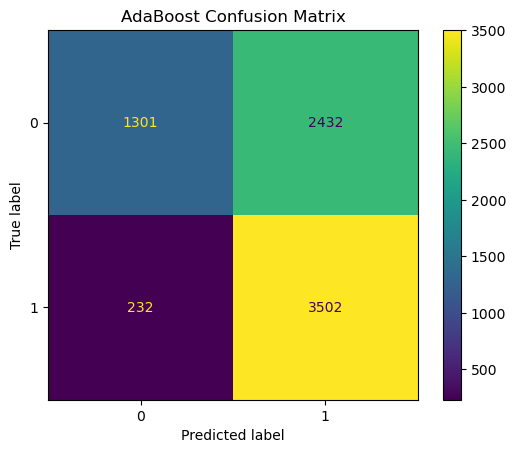

/Users/harperwood/miniconda3/envs/mlfund/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


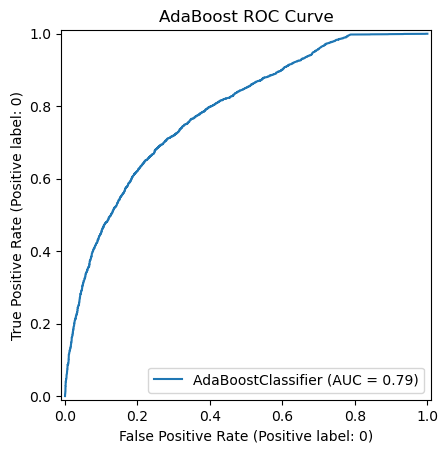

In [46]:
# confusion matrix and roc curve
cm = confusion_matrix(y_nutlin, y_hat_nutlin)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_model_ada.classes_)
disp.plot()
plt.title("AdaBoost Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(full_model_ada, X_nutlin, y_nutlin, pos_label=0)
plt.title("AdaBoost ROC Curve")
plt.show()

We can see here that the model is overpredicting functional labels for those members of the nonfunctional class. 